In [3]:
import itertools

with open("names.txt") as f:
    words = f.read().splitlines()

len(words)

type(words)

list

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
words[:1][0][1:]

'mma'

In [6]:
for w in words[:1]:
    w = ["<s>"] + list(w) + ["<e>"]
    for ch1, ch2 in itertools.pairwise(w):  # also zip(w,w[1:])
        print(
            ch1,
            ch2,
        )
    print("\n")

<s> e
e m
m m
m a
a <e>




In [11]:
# build each pair
char_pairs = {}
for w in words:
    w = ["."] + list(w) + ["."]
    for ch1, ch2 in itertools.pairwise(w):  # also zip(w,w[1:])
        bigram = (ch1, ch2)
        char_pairs[bigram] = (
            char_pairs.get(bigram, 0) + 1
        )  # char_pairs[ch1 + ch2] if ch1 + ch2 in char_pairs else 0

In [12]:
sorted(char_pairs.items(), key=lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

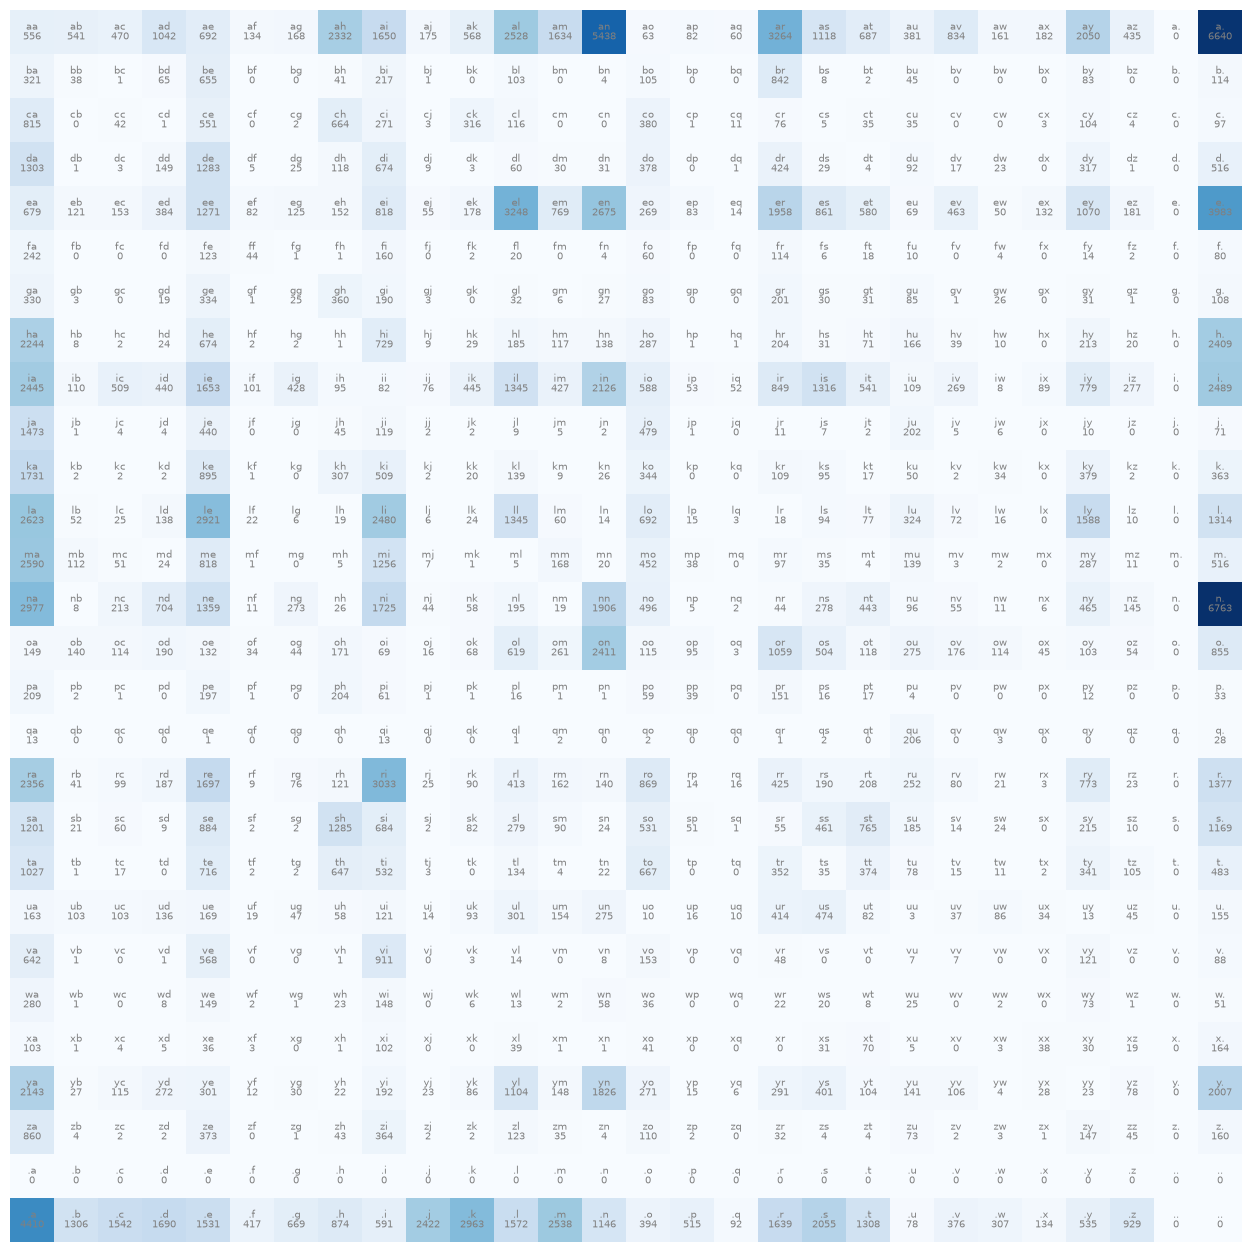

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# order: a-z, then the start/end tokens
chars = sorted(set("".join(words))) + [".", "."]
stoi = {ch: i for i, ch in enumerate(chars)}

# fill the count matrix: rows = first char, cols = second char
N = np.zeros((len(chars), len(chars)), dtype=int)
for (ch1, ch2), count in char_pairs.items():
    N[stoi[ch1], stoi[ch2]] = count

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(len(chars)):
    for j in range(len(chars)):
        plt.text(
            j,
            i,
            chars[i] + chars[j],
            ha="center",
            va="bottom",
            color="gray",
            fontsize=7,
        )
        plt.text(j, i, N[i, j], ha="center", va="top", color="gray", fontsize=7)
plt.axis("off")
plt.show()

In [16]:
import torch

In [20]:
n = torch.zeros((28, 28), dtype=torch.int32)

In [21]:
# build each pair
for w in words:
    w = ["."] + list(w) + ["."]
    for ch1, ch2 in itertools.pairwise(w):  # also zip(w,w[1:])
        n[stoi[ch1]][stoi[ch2]] += 1
n

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,